# Heart Rate Analysis Panel

This panel analyses the coherence of heart rate against firing rate for the spontaneously firing cells.

In [1]:
# Autoreloading of modules and files without restarting notebook.
%reload_ext autoreload
%autoreload 2

import os
import neo
import pickle
import numpy as np
import pandas as pd
from quantities import s
from copy import deepcopy
import matplotlib.pyplot as plt
from scipy.signal import detrend
from collections import defaultdict
from elephant.kernels import GaussianKernel
from elephant.signal_processing import zscore
from rvm_analysis.colours import get_cell_colour
from elephant.conversion import BinnedSpikeTrain
from rvm_analysis.save_tools import save_in_folder
from elephant.statistics import instantaneous_rate
from rvm_analysis.data_loaders import read_dataset_by_protocol
from rvm_analysis.utils import import_neutral_cells, import_spontaneous_cells, import_on_off_trials, import_neutral_cells_extra,combine_datasets_into_data_manager
from rvm_analysis.multitaper_coherence import fisher_ci_msc, multitaper_spectra, segment_signal, surrogate_coherence_distribution, theoretical_coherence_threshold, theoretical_fw_threshold
from rvm_analysis.multitaper_coherence import get_fwer_global_threshold_surrogates
from collections import defaultdict
from elephant.spectral import multitaper_coherence
from rvm_analysis.utils import z_score




np.random.seed(3)
#! Force the backend back to matplotlib inline (after importing viziphant).
%matplotlib inline
print(plt.get_backend())

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

module://matplotlib_inline.backend_inline


In [2]:
def deprecated_dat_loading_from_spike2():
    dm_on_off_trials = import_on_off_trials()
    dm_neutral = import_neutral_cells()
    dm_spontaneous = import_spontaneous_cells()
    dm_neutral_extra = import_neutral_cells_extra()

    dm_combined = combine_datasets_into_data_manager(dm_spontaneous,dm_neutral,dm_neutral_extra)

dm_combined = read_dataset_by_protocol(['evoked/ongoing','ongoing'])

evoked ..\..\data\dandiset\sub-rat-1\sub-rat-1_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-10\sub-rat-10_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-11\sub-rat-11_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-12\sub-rat-12_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-13\sub-rat-13_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-14\sub-rat-14_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-15\sub-rat-15_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-16\sub-rat-16_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-17\sub-rat-17_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-18\sub-rat-18_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-19\sub-rat-19_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-2\sub-rat-2_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-20\sub-rat-20_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-21\sub-rat-21_ses-1.nwb
False
evoked ..\..\data\dandiset\sub-rat-22\sub-rat-22_ses-1.nwb
False
evoked ..\..\data\dandiset\su

In [3]:
with open("../../CUT_CELL_ACTIVITIES_unzeroed.pkl", "rb") as file:
    cut_spikes_ON, cut_spikes_OFF, cut_spikes_NEUTRAL, cut_spikes_NEUTRAL_extra = pickle.load(file)

data = {
    "ON": cut_spikes_ON,
    "OFF": cut_spikes_OFF,
    "NEUTRAL": cut_spikes_NEUTRAL,
    "NEUTRAL_extra": cut_spikes_NEUTRAL_extra
}


In [4]:
def time_slice_round_safe(spiketrain, t_start, t_stop):
        """
        #! Modified from the neo version to fix rounding errors in the new spiketrain when compared to the old.
        Creates a new :class:`SpikeTrain` corresponding to the time slice of
        the original :class:`SpikeTrain` between (and including) times
        :attr:`t_start` and :attr:`t_stop`. Either parameter can also be None
        to use infinite endpoints for the time interval.
        """
        _t_start = t_start
        _t_stop = t_stop
        if t_start is None:
            _t_start = -np.inf
        if t_stop is None:
            _t_stop = np.inf

        if _t_start > spiketrain.t_stop or _t_stop < spiketrain.t_start:
            # the alternative to raising an exception would be to return
            # a zero-duration spike train set at self.t_stop or self.t_start
            raise ValueError("A time slice completely outside the " "boundaries of the spike train is not defined.")

        indices = (spiketrain >= _t_start) & (spiketrain <= _t_stop)

        # Time slicing should create a deep copy of the object
        new_st = deepcopy(spiketrain[indices])

        new_st.t_start = _t_start
        new_st.t_stop = _t_stop
        if spiketrain.waveforms is not None:
            new_st.waveforms = spiketrain.waveforms[indices]

        return new_st

In [5]:
def plot_normed_smoothed_rates(sp1,sp2, t_start,t_stop=None, sample_spacing = 1*s,kernel_width = 5*s,ax=None,linewidth=1):
    kernel = GaussianKernel(kernel_width)
    heart_rate: neo.AnalogSignal = instantaneous_rate(sp1,
                                                    sample_spacing,kernel=kernel,border_correction=True,t_start=t_start,t_stop=t_stop
                                                    )

    spike_rates: neo.AnalogSignal = instantaneous_rate(sp2, sample_spacing, kernel=kernel,border_correction=True,t_stop=t_stop)
    # print(spiketrain.t_start,spiketrain.t_stop,heart_rate.t_start,heart_rate.t_stop,)
    heart_rate = heart_rate.time_slice(t_start+10*s,t_stop-20*s) #!Remove the end because one of the recordings finishes at the end
    spike_rates = spike_rates.time_slice(t_start+10*s,t_stop - 20*s)


    #! Z score the rates
    normed_spike_rates = zscore(spike_rates)
    normed_heart_rate = zscore(heart_rate)

    sr = normed_spike_rates
    hr = normed_heart_rate

    plt.plot(sr.times,sr.magnitude,color=get_cell_colour(sp2),label=f"{sp2.name} #{sp2.description}",linewidth=linewidth)
    plt.plot(hr.times,hr.magnitude,color='black',label='heartrate',linewidth=linewidth)
    plt.ylabel("Normed\nRate",fontsize=7)
    # plt.legend()
    return sr,hr

In [6]:
def plot_cohe(sample_freq,sample_coh,file_name,cell_type,description,global_thr,alpha,surr,C_lo, C_hi,save=False):
    print(file_name, "Desc:", description)
    fig,ax = plt.subplots(figsize=(3,1))
    ax.spines[["right","top"]].set_visible(False)
    # cohs = np.array(cohs)
    # upper_quantile = np.quantile(cohs,1-p,axis=0)
    # lower_quantile = np.quantile(cohs,p,axis=0)
    # plt.fill_between(freqs[0],lower_quantile,upper_quantile,alpha=0.5,label=f"{1-alpha} %")
    # plt.plot(freqs[0],np.mean(cohs,axis=0),label="perm. mean")
    plt.plot(sample_freq,sample_coh,label="samp. coh",color=get_cell_colour(names=cell_type))
    plt.xlabel("Frequency (Hz)",fontsize=7)
    # plt.fill_between(sample_freq, C_lo, C_hi, alpha=0.3, label=f"Approx. {1-alpha}% CI")
    plt.hlines(global_thr,*plt.xlim(),color='black',label=f'max-stat.\n $\\alpha = {alpha}$')
    plt.ylabel("Coherence",fontsize=7)
    # plt.title(f"{file_name}, Sp: {description}")
    plt.xscale("log")
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    # plt.plot(sample_freq, surr, ":", label=f"H0 threshold (surrogate p={1-alpha})")

    plt.legend(fontsize=7,loc="upper right")
    save_in_folder(f"cohe_{cell_type}_{description}",svg=True,save=save)

def get_sig_coh_freqs(level,lower,upper,cohs,sample_freq,sample_coh):
    cohs = np.array(cohs)
    upper_quantile = np.quantile(cohs,level,axis=0)

    return sample_freq[np.where((sample_coh > upper_quantile) & (sample_freq > lower) & (sample_freq < upper))]

def get_sig_coh_freqs_value(value,lower,upper,sample_freq,sample_coh):
    return sample_freq[np.where((sample_coh > value) & (sample_freq > lower) & (sample_freq < upper))]

### Running the coherence Estimator across cells

In [7]:

def run_binned_spike_analysis(save= False,desc=None,cell_type_id=None,save_image=False,plot_only=False,save_rate_plot=False,linewidth=1):
    results = []
    for cell_type, spikes in data.items():
        if cell_type_id is not None:
            if cell_type != cell_type_id:
                continue
        for spiketrain in spikes:
            if desc is not None and spiketrain.description != desc:
                continue
            plt.rcParams["xtick.labelsize"] = 7
            plt.rcParams["ytick.labelsize"] = 7
            fig, ax  = plt.subplots(figsize=(7.5,0.7))
            ax.spines[["right","top"]].set_visible(False)
            # print(spike.file_origin)
            file_name = os.path.split(spiketrain.file_origin)[-1][:-5].split("\\")[-1]

            for block in dm_combined.blocks:
                block: neo.Block  = block
                if block.file_origin.stem == file_name:
                    for event in block.segments[0].events:
                        if event.name in dm_combined.heart_rate_channel:
                            heart_beats: neo.SpikeTrain = neo.SpikeTrain(event,event[-1],s)
            
            # fig, ax = plt.subplots(figsize=(25,3))
            heart_beat_pre_sliced = time_slice_round_safe(heart_beats,spiketrain.t_start,spiketrain.t_stop)
            
            assert(spiketrain.t_stop == heart_beat_pre_sliced.t_stop)

            ax.eventplot([spiketrain.magnitude],linewidth=0.05,lineoffsets=4,colors=[get_cell_colour(spiketrain)])

            sr,hr = plot_normed_smoothed_rates(heart_beat_pre_sliced,spiketrain, #! Using a different kernel width to the frequency plots for ease of viewing
                                       t_start=spiketrain.t_start,t_stop=spiketrain.t_stop,
                                       sample_spacing=1*s,kernel_width=5*s,ax=ax,linewidth=linewidth)

            save_in_folder(f"Norm Heart Rate against Spikes {spiketrain.name}_{spiketrain.description}",
                           svg=True,save=save_rate_plot,dpi=1200)
            if not plot_only:
                bin_size = 2*s
                fs = 1/ bin_size.magnitude

                binned_spikes = BinnedSpikeTrain(
                    spiketrain,
                    bin_size=bin_size,
                    )#.to_array()
                binned_spikes1 = BinnedSpikeTrain(
                    heart_beat_pre_sliced,
                    bin_size=bin_size,
                    )#.to_array()

                bsa = binned_spikes.to_array().flatten()
                bsa1 = binned_spikes1.to_array().flatten()

                # #! Testing sine waves for frequency
                # f_test = 0.005 * Hz
                # t = np.linspace(0,bin_size.magnitude*bsa.size,bsa.size) * s
                # bsa = np.sin(2*np.pi*f_test*t) + np.random.normal(0,0.5,bsa.shape)
                # bsa1 = np.sin(2*np.pi*f_test*t+2) + np.random.normal(0,0.1,bsa.shape)
                # fig ,ax = plt.subplots()
                # plt.plot(t,bsa)
                # plt.plot(t,bsa1)
                # plt.show()

                # print(bsa.shape[1] * 1e-3 / 2)
                def coherence_func(x1,x2):
                    x1 = detrend(x1,axis=-1,type='linear')
                    x2 = detrend(x2,axis=-1,type='linear')
                    return multitaper_coherence(z_score(x1),z_score(x2),n_segments=1,fs=1/bin_size)
                
                ###! This is the part that needs to be rewritten
                seg_len = int(500*fs) # 500 second windows
                step = seg_len // 2     # 50% overlap
                NW = 3.5
                K = 6#None        # default K = floor(2*NW-1)
                alpha = 0.001

                #* segment first
                # print(len(bsa),seg_len)
                x_segs = segment_signal(bsa, seg_len, step)
                y_segs = segment_signal(bsa1, seg_len, step)

                #* Then compute the sample spectrum
                f, Sxx, Syy, Sxy, C, N_avg, K = multitaper_spectra(x_segs, y_segs, fs, NW=NW, K=K, detrend=True)

                print(N_avg)
                #* then get exact variance estimates from fischer
                C_lo, C_hi = fisher_ci_msc(C, N_avg, alpha=alpha)


                #* Then get a surrogate distribution
                f_surr, C_surr, _, _ = surrogate_coherence_distribution(
                    x_segs, y_segs, fs, NW, K,
                    n_iter=1000, detrend=True, seed=1
                )
                surr = np.percentile(C_surr, 100*(1-alpha), axis=0)

                #* Then get a max-statistic bound
                global_thr = get_fwer_global_threshold_surrogates(C_surr,alpha)

                sig_freqs = get_sig_coh_freqs_value(global_thr,0.0,1e3,f,C)


                ###! I need to return the surrogate frequencies, coherences, samples, everything needed by results.

                plot_cohe(f,C,file_name,cell_type,spiketrain.description,global_thr,alpha,surr,C_lo,C_hi,save=save_image)

                result = {
                    "file_name": file_name,
                    "cell_type": cell_type,
                    "description": spiketrain.description,
                    "sample_freqs": f,
                    "sample_cohs": C,
                    "permuted_freqs": f,
                    "permuted_cohs": C_surr,
                    "global_thr": global_thr,
                    "sig_freqs": sig_freqs
                }
                results.append(result)

    results_df = pd.DataFrame(results)
    return results_df if save else None

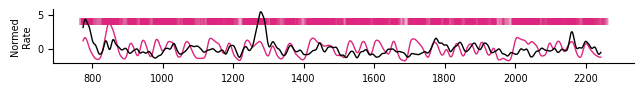

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Naive 4-16-24 a ON@2390_cut_pared Desc: 0


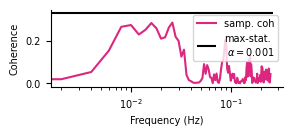

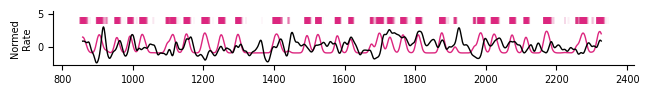

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Naive 4-16-24 b ON@2765_cut_pared Desc: 1


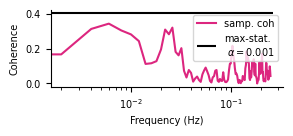

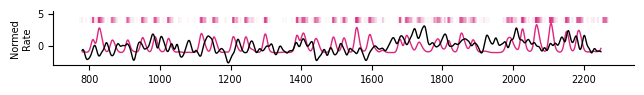

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Naive 4-16-24 c OFF&ON@2935_cut_pared Desc: 3


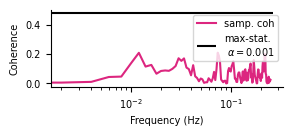

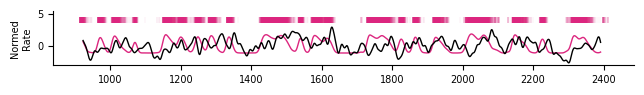

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-17-24 a ON@1695_cut_pared Desc: 4


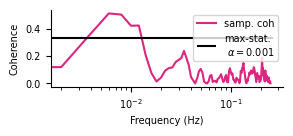

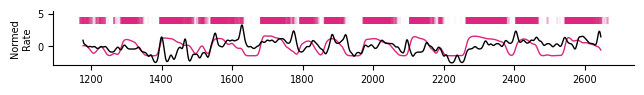

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-18-24 #1 ON&OFF@2120_cut_pared Desc: 5


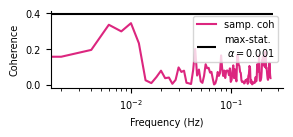

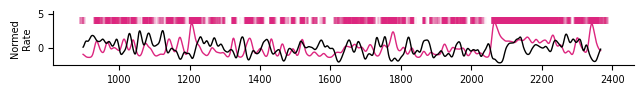

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-23-24a ON@2249_cut_pared Desc: 9


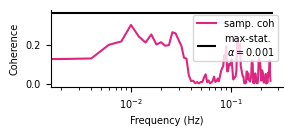

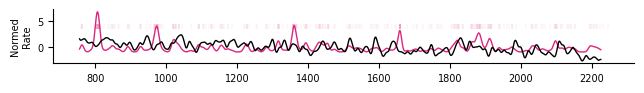

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-23-24b OFF&ON@3244_cut_pared Desc: 10


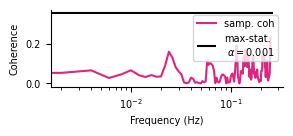

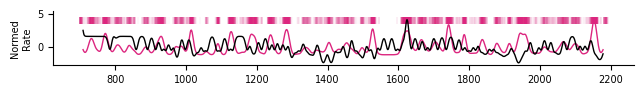

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-25-24a ON@2646_cut_pared Desc: 12


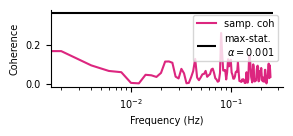

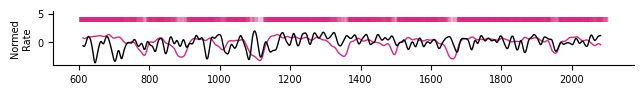

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-30-24b ON@2455_cut_pared Desc: 18


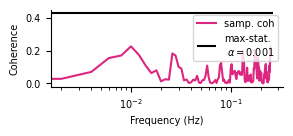

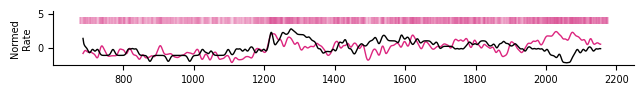

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 5-1-24c ON@2934_cut_pared Desc: 21


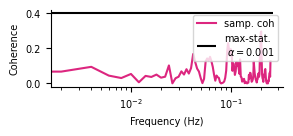

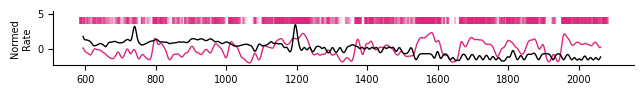

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing01a_cut_pared Desc: 24


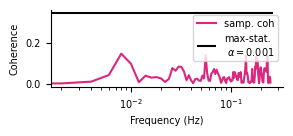

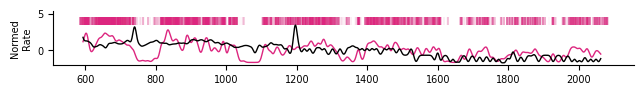

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing01a_cut_pared Desc: 25


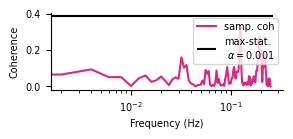

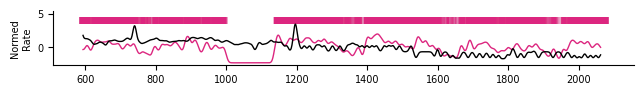

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing01a_cut_pared Desc: 26


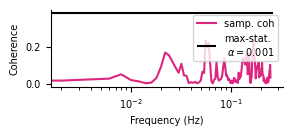

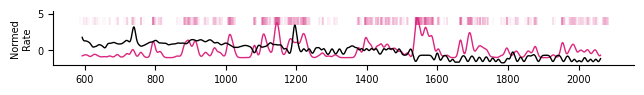

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing01a_cut_pared Desc: 28


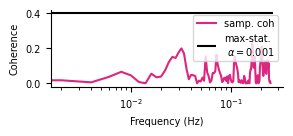

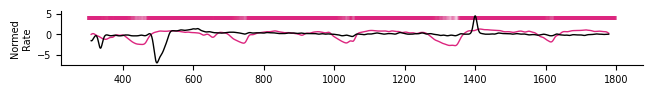

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing02a_cut_pared Desc: 30


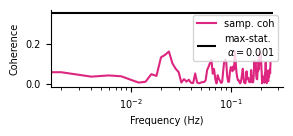

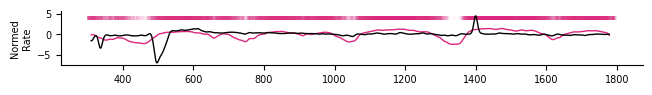

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing02a_cut_pared Desc: 31


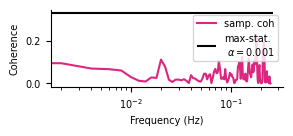

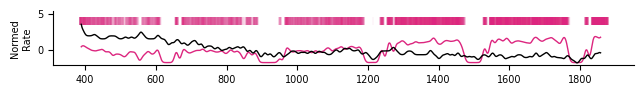

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing02b_cut_pared Desc: 32


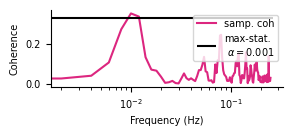

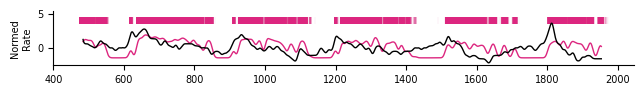

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing02c_cut_pared Desc: 33


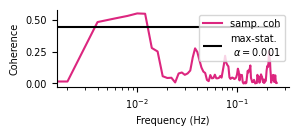

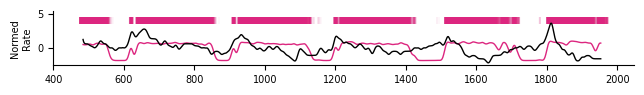

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing02c_cut_pared Desc: 34


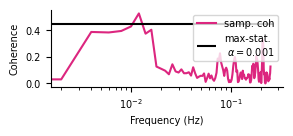

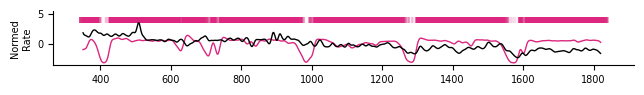

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing05a_cut_pared Desc: 40


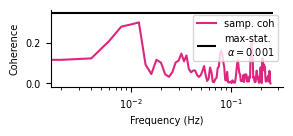

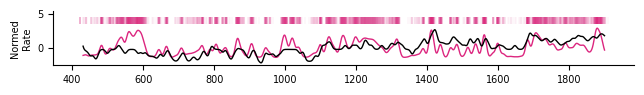

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing05b_cut_pared Desc: 42


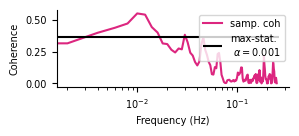

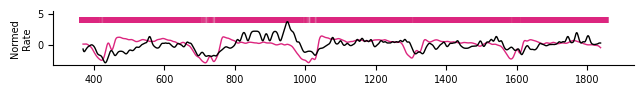

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing06a_cut_pared Desc: 43


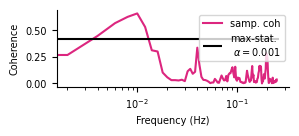

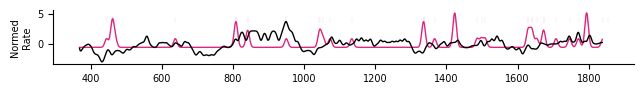

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing06a_cut_pared Desc: 44


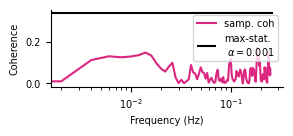

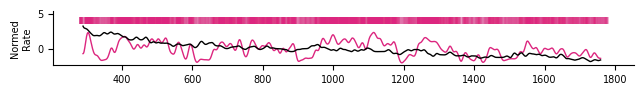

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing08a_cut_pared Desc: 48


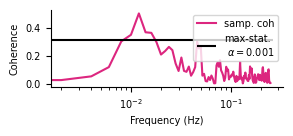

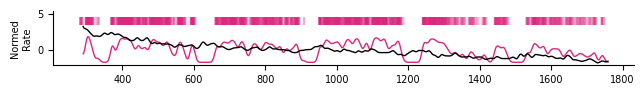

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing08a_cut_pared Desc: 49


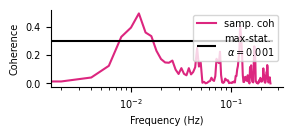

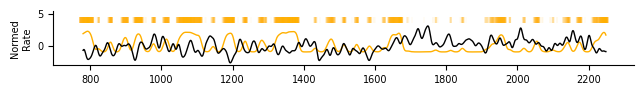

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Naive 4-16-24 c OFF&ON@2935_cut_pared Desc: 2


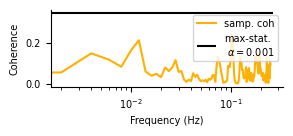

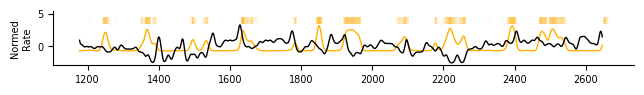

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-18-24 #1 ON&OFF@2120_cut_pared Desc: 6


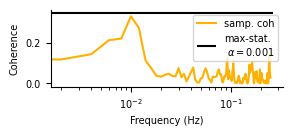

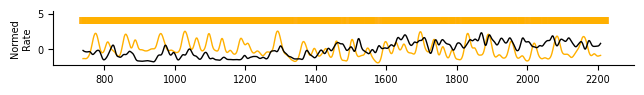

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-22-24a OFF@2465_cut_pared Desc: 7


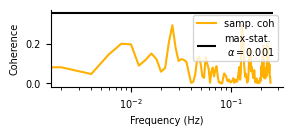

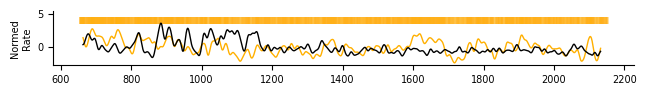

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-22-24b OFF@2068_cut_pared Desc: 8


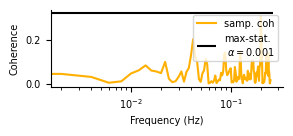

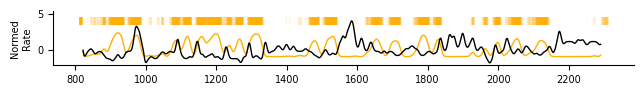

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-24-24a OFF@1665_cut_pared Desc: 11


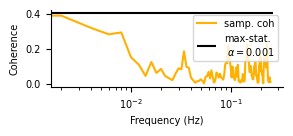

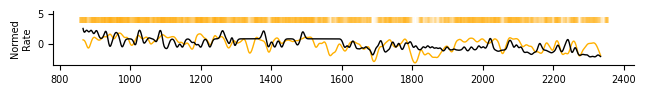

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-25-24b OFF@3009_cut_pared Desc: 13


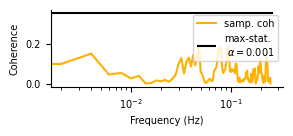

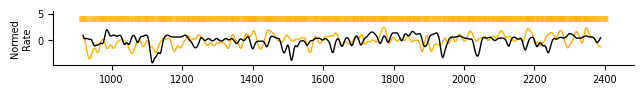

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-29-24a OFF@2839_cut_pared Desc: 14


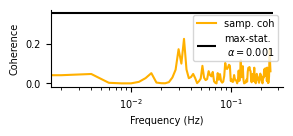

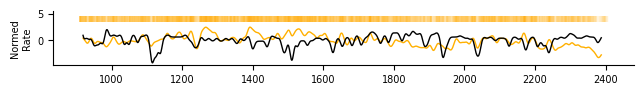

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-29-24a OFF@2839_cut_pared Desc: 15


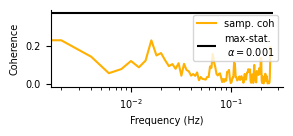

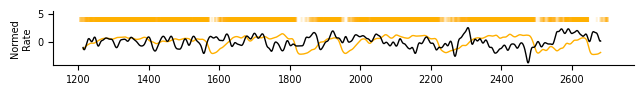

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-30-24a OFF@2789_cut_pared Desc: 16


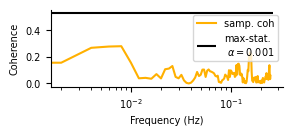

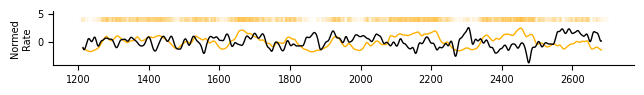

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 4-30-24a OFF@2789_cut_pared Desc: 17


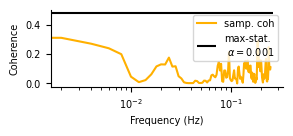

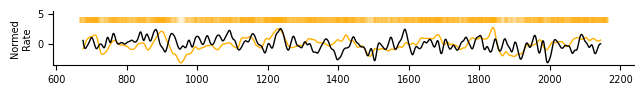

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 5-1-24a OFF@2302_cut_pared Desc: 19


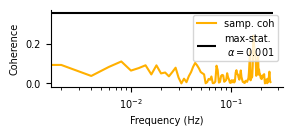

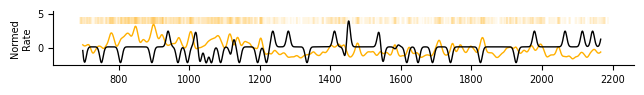

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 5-1-24b OFF@2540_cut_pared Desc: 20


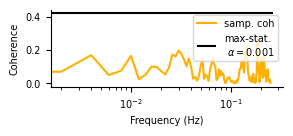

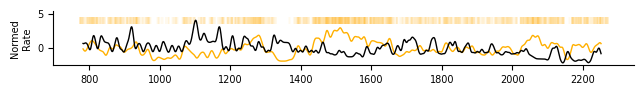

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 5-2-24a OFF@2030_cut_pared Desc: 22


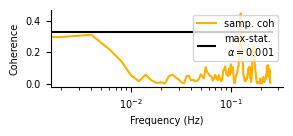

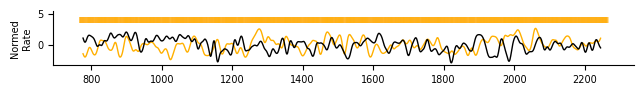

[  0 125 250 375 500]
[  0 125 250 375 500]
30
ZS Naive 5-2-24b OFF@2632_cut_pared Desc: 23


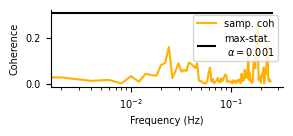

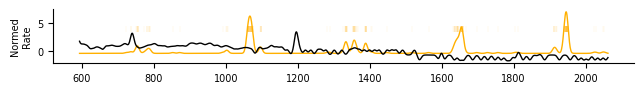

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing01a_cut_pared Desc: 27


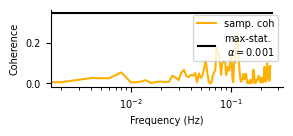

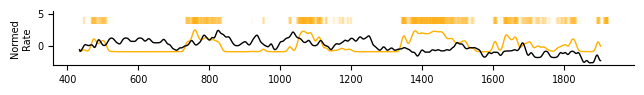

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing01b_cut_pared Desc: 29


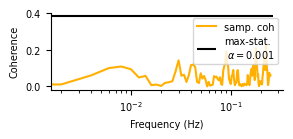

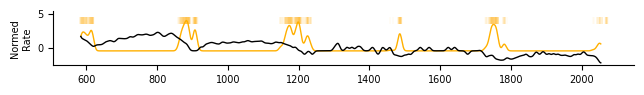

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing03a_cut_pared Desc: 35


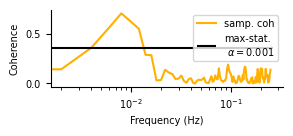

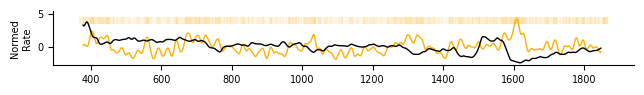

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing03b_cut_pared Desc: 36


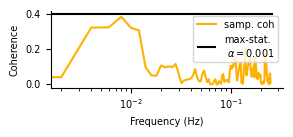

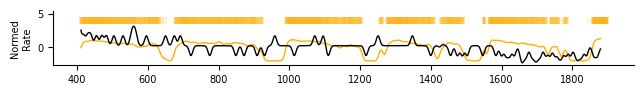

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing04a_cut_pared Desc: 37


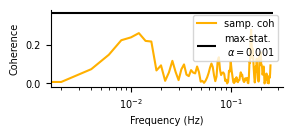

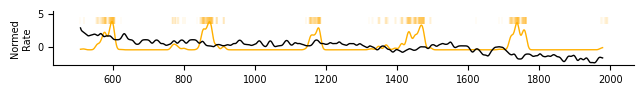

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing04b_cut_pared Desc: 38


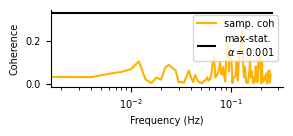

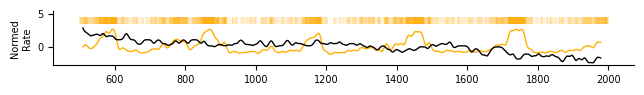

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing04b_cut_pared Desc: 39


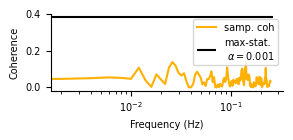

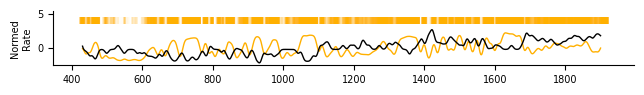

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing05b_cut_pared Desc: 41


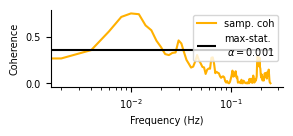

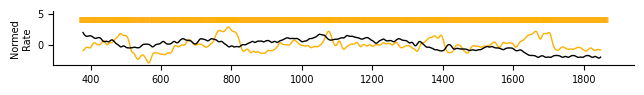

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing06b_cut_pared Desc: 45


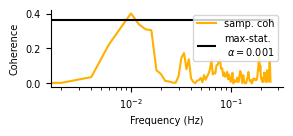

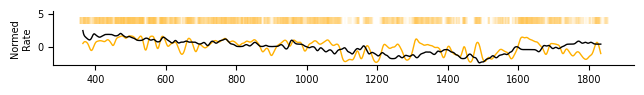

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing07a_cut_pared Desc: 46


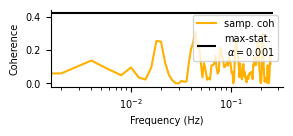

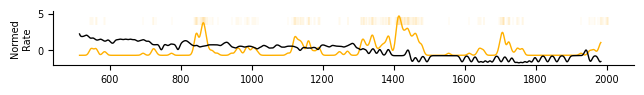

[  0 125 250 375 500]
[  0 125 250 375 500]
30
CA_ongoing07b_cut_pared Desc: 47


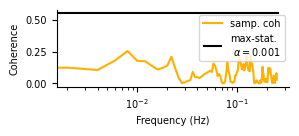

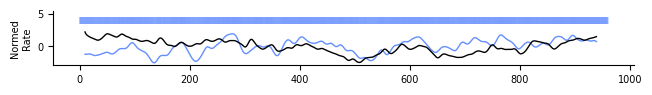

[  0 125]
[  0 125]
12
HDB_Bic09_cut_truncated Desc: 0


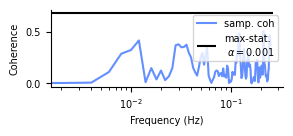

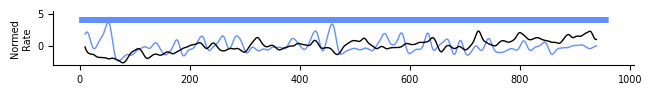

[  0 125]
[  0 125]
12
HDB_Bic115_cut_truncated Desc: 1


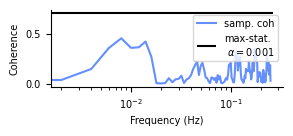

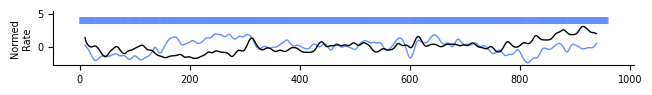

[  0 125]
[  0 125]
12
HDB_Bic12_cut_truncated Desc: 2


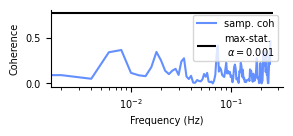

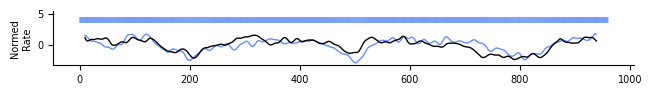

[  0 125]
[  0 125]
12
HDB_Bic125_cut_truncated Desc: 3


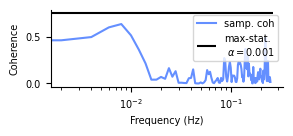

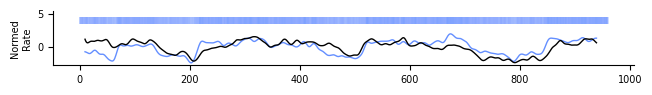

[  0 125]
[  0 125]
12
HDB_Bic125_cut_truncated Desc: 4


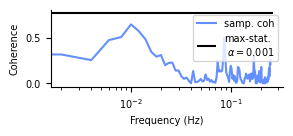

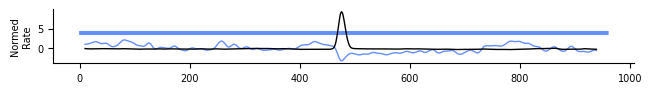

[  0 125]
[  0 125]
12
HDB_Bic42_cut_truncated Desc: 5


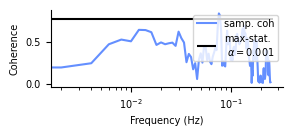

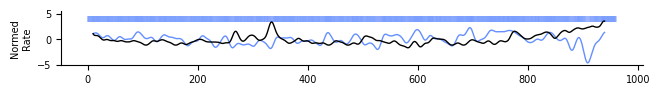

[  0 125]
[  0 125]
12
HDB_Bic43_cut_truncated Desc: 6


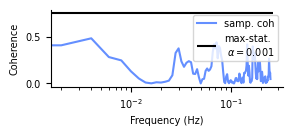

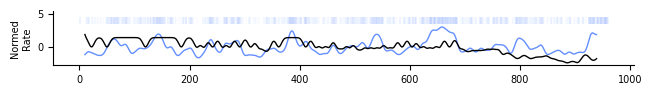

[  0 125]
[  0 125]
12
HDB_Bic47_cut_truncated Desc: 7


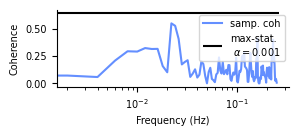

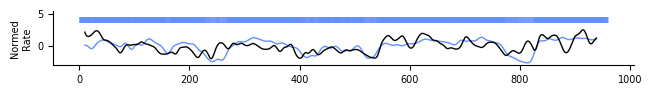

[  0 125]
[  0 125]
12
HDB_Bic48_cut_truncated Desc: 8


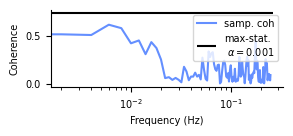

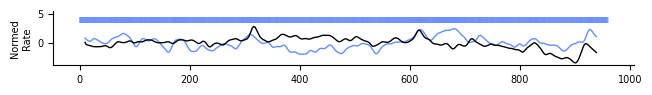

[  0 125]
[  0 125]
12
HDB_Bic51_cut_truncated Desc: 9


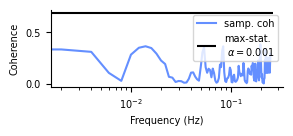

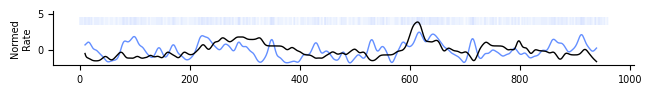

[  0 125]
[  0 125]
12
HDB_Bic56_cut_truncated Desc: 10


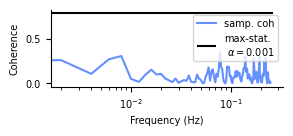

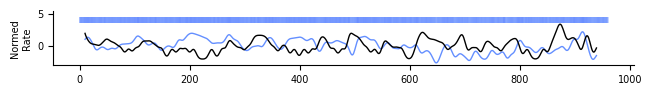

[  0 125]
[  0 125]
12
HDB_Bic57_cut_truncated Desc: 11


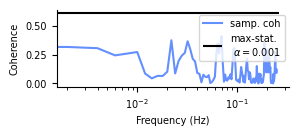

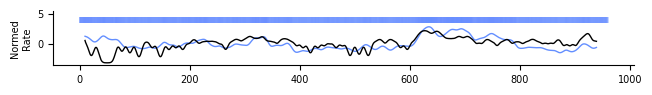

[  0 125]
[  0 125]
12
HDB_Bic58_cut_truncated Desc: 12


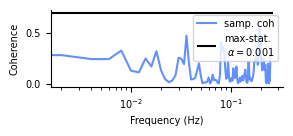

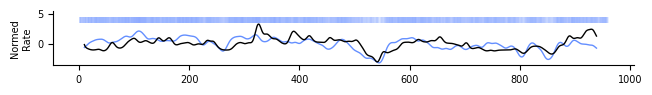

[  0 125]
[  0 125]
12
HDB_Bic62_cut_truncated Desc: 13


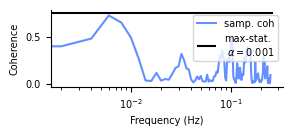

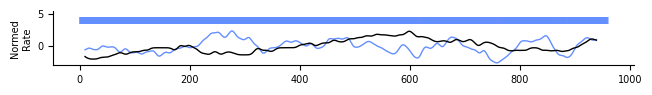

[  0 125]
[  0 125]
12
HDB_Bic67_cut_truncated Desc: 14


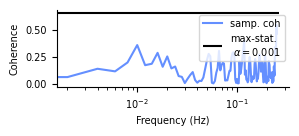

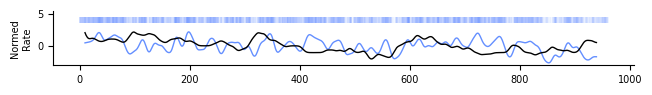

[  0 125]
[  0 125]
12
HDB_Bic72_cut_truncated Desc: 15


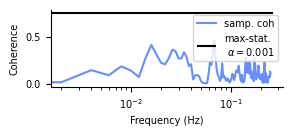

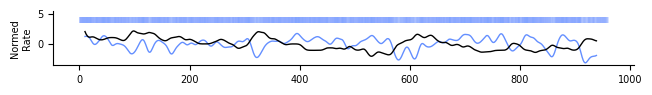

[  0 125]
[  0 125]
12
HDB_Bic72_cut_truncated Desc: 16


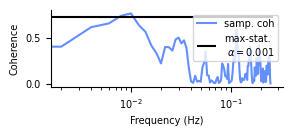

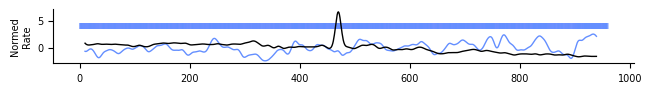

[  0 125]
[  0 125]
12
HDB_Bic73_cut_truncated Desc: 17


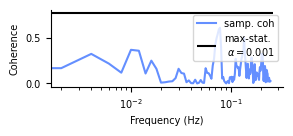

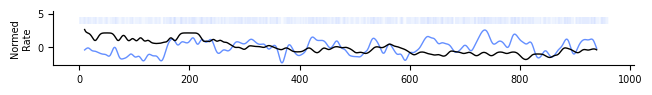

[  0 125]
[  0 125]
12
HDB_Bic79_cut_truncated Desc: 18


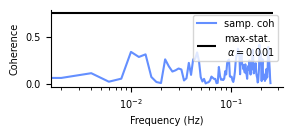

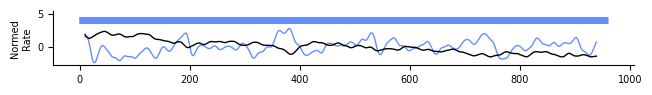

[  0 125]
[  0 125]
12
HDB_Bic80_cut_truncated Desc: 19


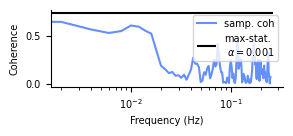

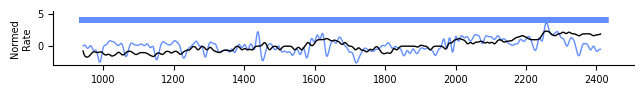

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 7-17-24 @1165_Pared Desc: 50


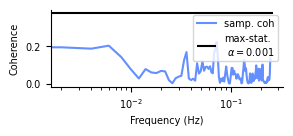

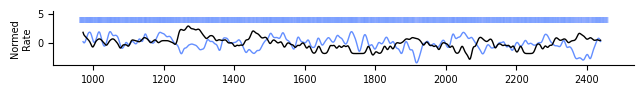

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 7-19-24@2583_pared Desc: 51


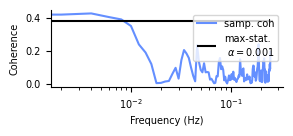

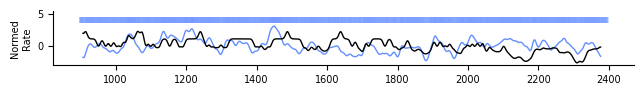

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 7-31-24@2940_pared Desc: 52


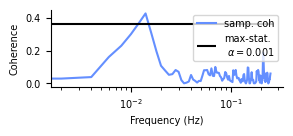

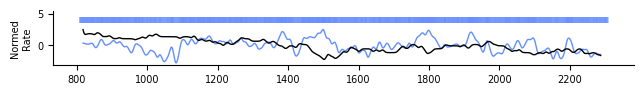

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 8-1-24@2827_pared Desc: 53


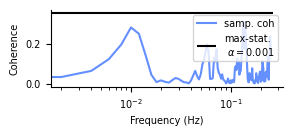

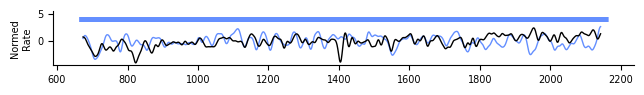

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 8-14-24@1505_pared Desc: 54


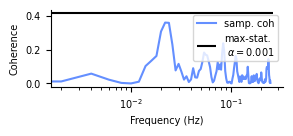

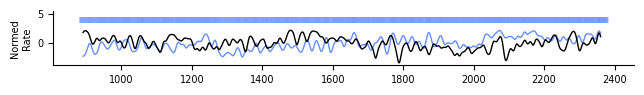

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 8-15-24@4020_pared Desc: 55


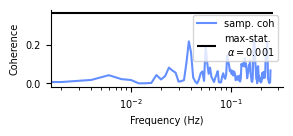

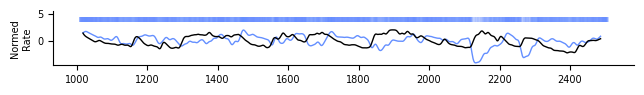

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral Ongoing 8-29-24 @2950_pared Desc: 56


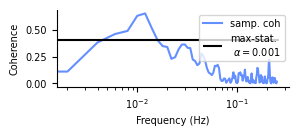

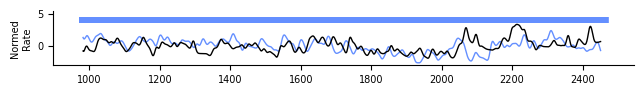

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 8-7-24 #1@2797_pared Desc: 57


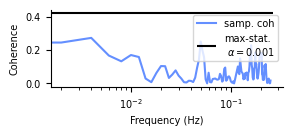

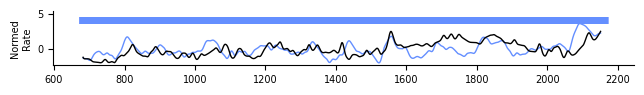

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 8-7-24 #2@2984_pared Desc: 58


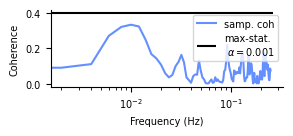

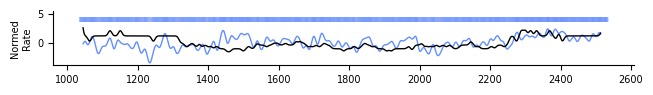

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 8-8-24@3195_pared Desc: 59


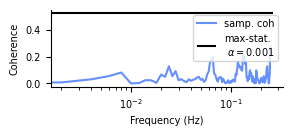

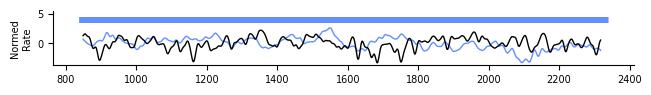

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 9-4-24 @2670_pared Desc: 60


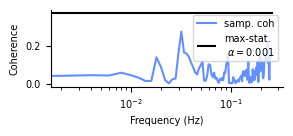

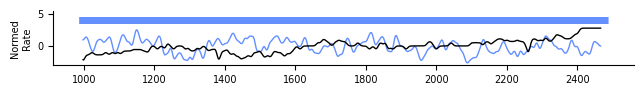

[  0 125 250 375 500]
[  0 125 250 375 500]
30
Neutral ongoing 9-5-24 neutral@2749_pared Desc: 61


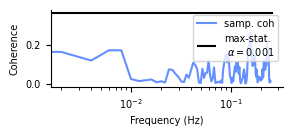

In [12]:
linewidth=1
# results_df = run_binned_spike_analysis(save=False,desc=16,save_image=True,cell_type_id="NEUTRAL",
#     plot_only=True,save_rate_plot=True,linewidth=linewidth)
# results_df = run_binned_spike_analysis(save=False,desc=9,save_image=True,cell_type_id="ON",
#     plot_only=True,save_rate_plot=True,linewidth=linewidth)
# results_df = run_binned_spike_analysis(save=False,desc=45,save_image=True,cell_type_id="OFF",
#     plot_only=True,save_rate_plot=True,linewidth=linewidth)
results_df = run_binned_spike_analysis(save=True,desc=None,save_image=False,cell_type_id=None,plot_only=False)


In [ ]:
if False:
    with open("pickled_coherence_results.pkl",'rb') as f:
        results_df = pickle.load(f)

    for idx, row in results_df.iterrows():
        plot_cohe(
            row['permuted_freqs'],
            row['permuted_cohs'],
            row['sample_freqs'],
            row['sample_cohs'],
            row['file_name'],
            row['cell_type'],
            row['description']
        )

In [9]:
filename = "pickled_coherence_results_segment_demean"


In [ ]:
with open(filename,'rb') as f:
    results_df = pickle.load(f)

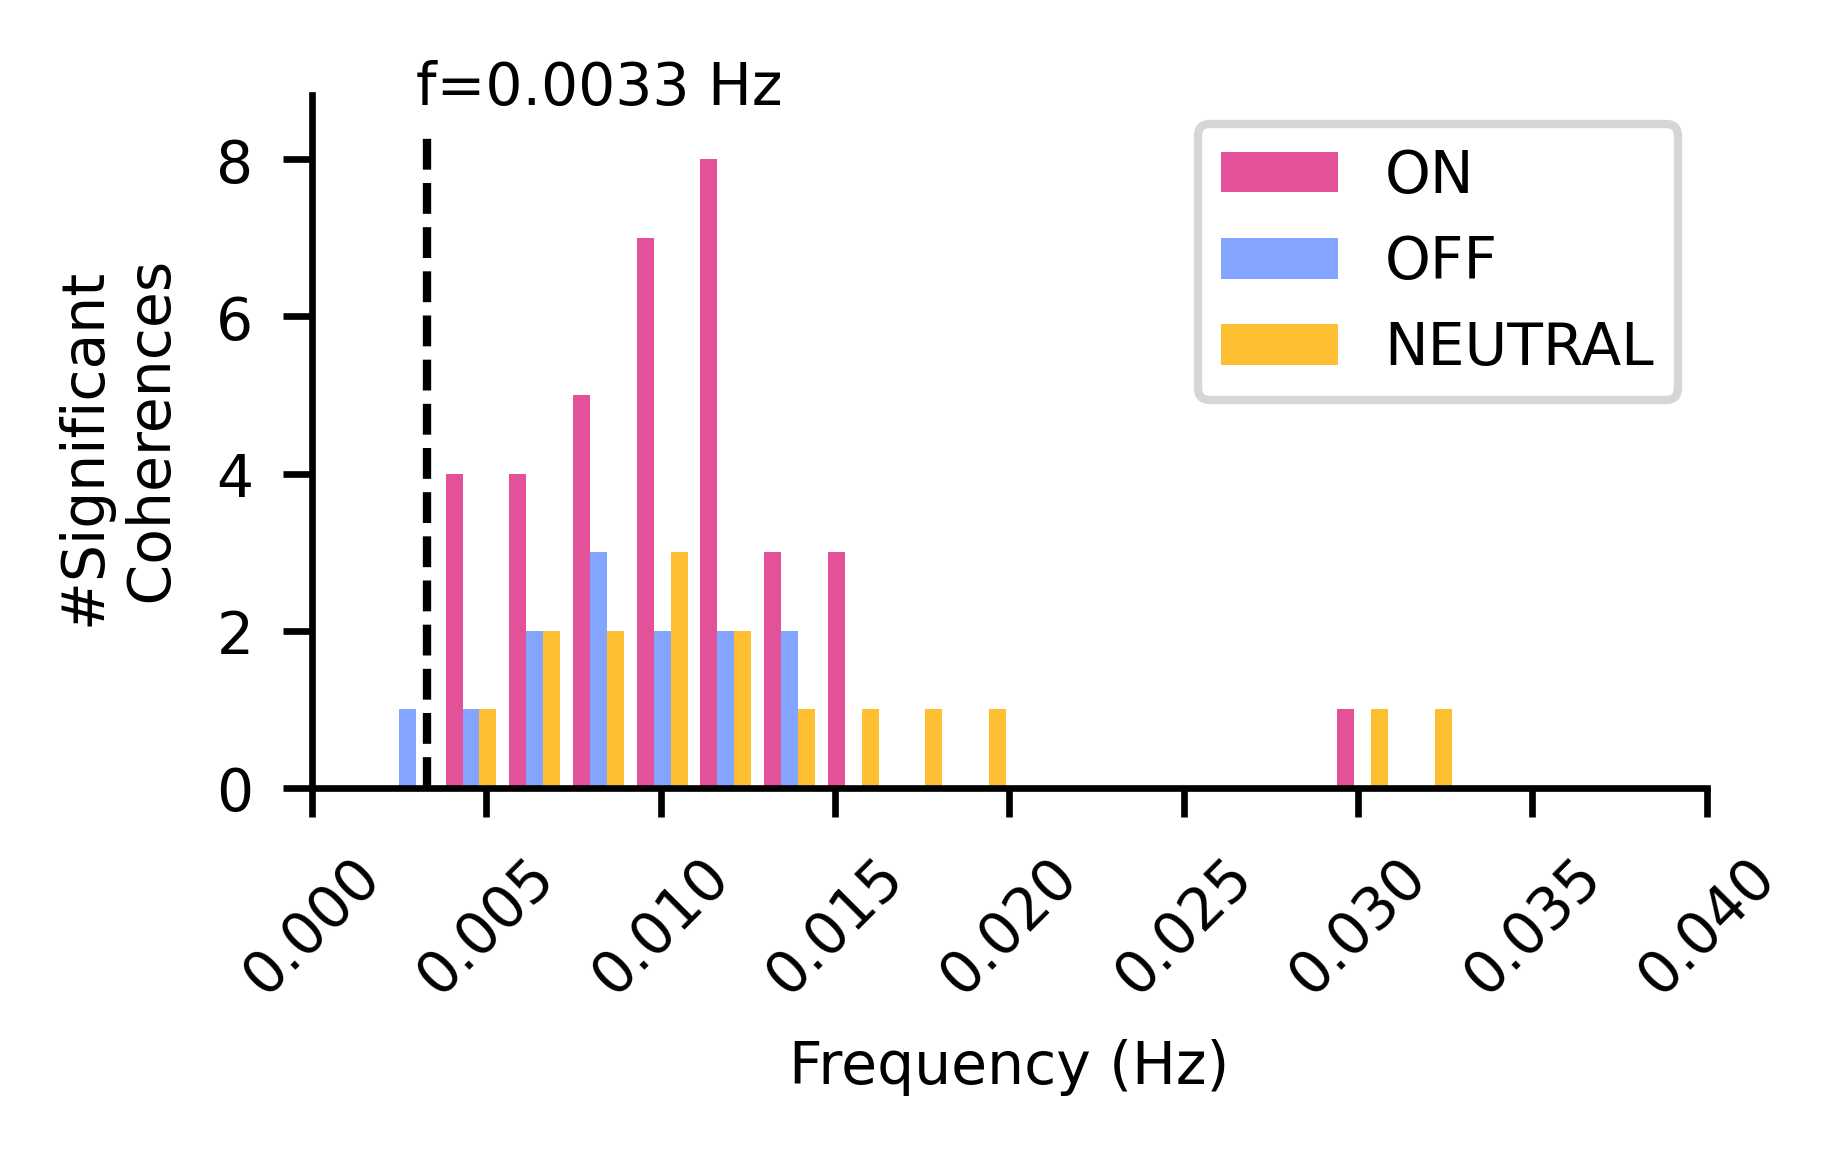

In [13]:
def find_sig_coherences_all(results_df):
    results_df['coherence'] = ""
    sig_coh_freqs = defaultdict(lambda : [])

    for idx, row in results_df.iterrows():
        sig_freqs = row['sig_freqs']
        if len(sig_freqs) == 0:
            results_df.at[idx,'coherence'] = False
        else:
            results_df.at[idx, 'coherence'] = True
        sig_coh_freqs[row['cell_type']].extend(sig_freqs)

    return sig_coh_freqs


sig_coh_freqs = find_sig_coherences_all(results_df)
fig, ax = plt.subplots(figsize=(3,1.5),dpi=600)

ax.spines[["top","right"]].set_visible(False)
bins=np.linspace(0,
                 np.max(
                     [np.max(x) for x in [
                         np.array(sig_coh_freqs['ON']),np.array(sig_coh_freqs['OFF']),np.array(sig_coh_freqs['NEUTRAL'] + sig_coh_freqs['NEUTRAL_extra'])
                         ]])
                     ,70)
plt.hist([np.array(sig_coh_freqs['ON']),np.array(sig_coh_freqs['NEUTRAL'] + sig_coh_freqs['NEUTRAL_extra']),np.array(sig_coh_freqs['OFF'])],bins=bins,alpha=0.8,color=get_cell_colour(names=["ON",'NEUTRAL','OFF']))
# plt.hist(,bins=bins,alpha=0.8,color=get_cell_colour(names="NEUTRAL"),label='NEUTRAL')
# plt.hist(,bins=bins,alpha=0.5,color=get_cell_colour(names="OFF"),label='OFF')
# plt.xscale("log")
plt.xlabel("Frequency (Hz)",fontsize=7)
plt.legend(["ON",'OFF',"NEUTRAL"],fontsize=7)
plt.vlines(0.0033,*plt.ylim(), linestyle="--",color='black',linewidth=1) #! Make sure this is the mean found frequency for the GP fits
plt.ylabel("#Significant \n Coherences",fontsize=7)
import matplotlib.ticker as ticker
ax.tick_params("both",labelsize=7)
ax.text(0.003,y=8.7,s="f=0.0033 Hz",fontsize=7)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005, offset=0.000))
ax.tick_params("x", rotation=45)# plt.xlim(0,0.1)
plt.xlim(0,0.04)
save_in_folder("coherences_against_heart_rate",svg=True,show=True,save=False)

In [ ]:
for key, res in results_df.groupby(['cell_type',"coherence"]):
    print(key)
    print(len(res))

('NEUTRAL', False)
18
('NEUTRAL', True)
2
('NEUTRAL_extra', False)
9
('NEUTRAL_extra', True)
3
('OFF', False)
21
('OFF', True)
4
('ON', False)
17
('ON', True)
8


In [ ]:
results_df[["file_name","cell_type","description","coherence"]].to_excel("coherence_df.xlsx")

In [ ]:
if True:
    with open(filename, 'wb') as pickled_results_file:
        pickle.dump(results_df, pickled_results_file)

In [ ]:
def create_cell_info_spreadsheet(data):
    trains = defaultdict(lambda : [])
    for cell_type, spikes in data.items():
        for spiketrain in spikes:
            # fig = plt.figure(figsize=(25,5))
            # print(spike.file_origin)
            file_name = os.path.split(spiketrain.file_origin)[-1][:-5].split("\\")[-1]
            trains["file_name"].append(file_name)
            trains["description"].append(spiketrain.description)
            trains["name"].append(spiketrain.name)

    import pandas as pd
    trains_df = pd.DataFrame(trains) 
    trains_df.to_excel("coherence_df.xlsx")

In [ ]:
# import pandas as pd
# coherence_df = pd.read_excel("coherence_df.xlsx",index_col=0)
# coherence_df

# for key, res in coherence_df.groupby(["name","coherence"]):
#     print(key)
#     print(len(res))